[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Humboldt-WI/delta/blob/master/tutorial_notebooks/Tut8_Attention_Student.ipynb)

# Tutorial 8: Multi-Headed Self-Attention in Transformer Neural Networks

In this Tutorial:
1. Standard Transformer Architecture
2. Positional Encoding
3. Multi Headed Self-Attention
4. Transformer Subtypes
5. Implementing a Transformer from scratch

In [4]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Standard Transformer Architecture

In the Transformer's encoder-decoder structure, text is first transformed into numeric values and then back into text after processing. Unlike RNNs, which process sequences step-by-step, the Transformer handles all tokens simultaneously. This parallelism improves efficiency but means the model has no innate sense of word order, so positional encoding is used to inject this crucial information. At the core of the architecture is the attention mechanism, which gives words contextual meaning by modeling their relationships with other words in the sequence. Multiple attention heads, eight in the original paper, enable the model to focus on different parts of a sentence simultaneously, capturing various linguistic patterns. To deepen its representational power, both the encoder and decoder are stacked six times in the standard architecture, allowing progressively more abstract feature extraction.

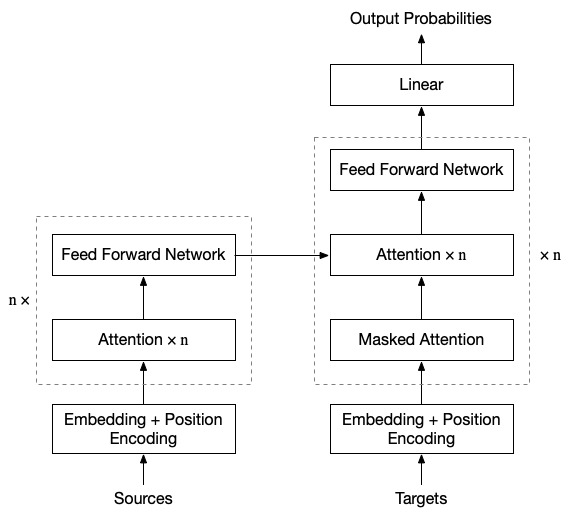

In the standard seq2seq transformer, output generation involves encoding the entire input sequence using the encoder, which produces a sequence of context-rich hidden states. These are then fed to the decoder, which generates the output sequence autoregressively—one token at a time. At each decoding step, the model takes the previously generated output tokens (or ground truth during training) and attends to the encoder’s output to predict the next token. This prediction is a probability distribution over the vocabulary, typically obtained via a softmax layer on top of the decoder’s output. The process repeats until an end-of-sequence token is produced or a maximum length is reached.


## 2. Positional Encoding

As the transformer network processes all words simultaneously, we must inject some information about the relative or absolute position to make use of the word order. This should happen after the word embedding and before the first encoder / decoder block.

The first way to do this, that comes to mind, is simply adding the word position $n$ as another dimension to the word embedding vectors. However, as the values of the word embeddings are usually bound within a narrow range, this would put too much importance on the position dimension for high positions. It is necesarry that the positional information is also bound.

One way to achieve this would be to use $1/n$. However, this would result in vanishing positional information for high positions. Another function one might consider is the Softmax function. It is bound between 0 and 1 and it displays a great deal of positional information in its middle part where the gradient is the steepest. However, independently of how one sets it up, the positional information will vanish for either very low or very high positions.

The solution that [[Vaswani et al., 2017]](#References) came up with is inspired by Fourier theory — they decided to use sinusoids of varying frequencies. Sinusoids, i.e. sine and cosine functions, are bound between $-1$ and $1$ and they repeat indefinitely, so they reflect the same amount of positional information for every position.

However, because they repeat, several positions may have the same value for each sinusoid. To achieve a unique positional representation the authors have decided not to attach the positional information as an additional dimension, but to add it up to every one of the 512 dimensions of the word vector. For each dimension, they used a different frequency and they alternated between sine and cosine functions, thereby creating a specific unique 512-dimensional vector for each position.

<div>
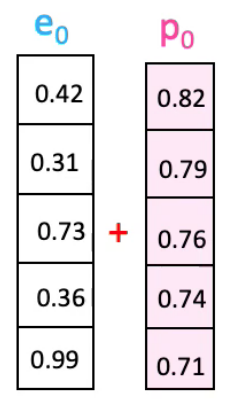
</div>

The positional vectors have the same dimension as the word embeddings. The positional encoding can be thought of as a nudge in each dimension in the 512-dimensional vector space. The intuition being: If the word embeddings reflect the meaning of the word, then the positional vector reflects the meaning of the position. Together they create the positionally encoded embeddings for each word. Word vectors can be viewed as points on a unit hypersphere, because only their relative directions capture semantic relationships. Positional encodings, then, can be interpreted as small perturbations or shifts in the vicinity of these points, effectively forming an area or neighborhood around each word vector. This allows the model to preserve meaning while injecting order, enabling attention mechanisms to remain position-aware without recurrence or convolution.



One way to implement positional encoding is through sinusoidal functions. Each position is mapped to a vector where the dimensions alternate between sine and cosine functions of different frequencies: for position pospos and dimension ii, the encoding is defined as

$$ PE_{(pos,2i)}=sin({pos \over 10000^{2i/dmodel}}) $$

$$ PE_{(pos,2i+1)}=cos({pos \over 10000^{2i/dmodel}}) $$

For each even dimenstion, the sine function is applied while for each odd dimension it is the cosine function. The wavelengths form a geometric progression from $2π$ to $10000⋅2π$. 

This approach ensures that nearby positions have similar encodings and that the model can learn to attend based on relative distances. It also allows the model to generalize to sequence lengths not seen during training. Interestingly, it yields similar downstream performance to learned positional encodings, where position vectors are trained like embeddings, suggesting that the key utility lies in breaking permutation symmetry rather than the specific encoding form.

In [ ]:
import torch
import torch.nn as nn
from torch.autograd import Variable

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + Variable(self.pe[:, :x.size(1)], 
                         requires_grad=False)
        return self.dropout(x)

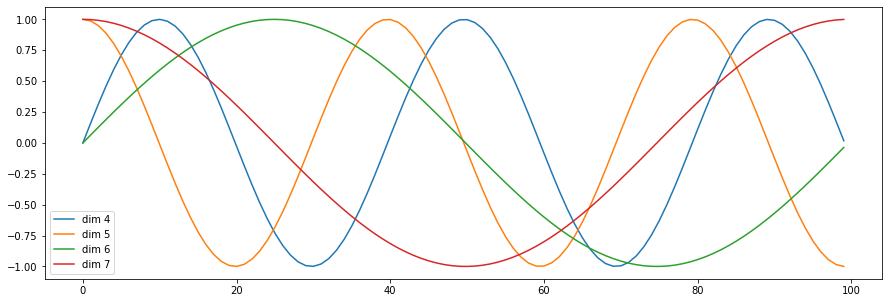

In [ ]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(Variable(torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(['dim %d'%p for p in [4,5,6,7]])
None

As you can see displayed in the plot above, the functions alternate between sine and cosine and the wavelength increases with each dimension. This allows the network to attend to positional information for an infinite amount of positions (theoretically, given enough computational resources) without any loss of precision.

E.g. for a word at position 20, the green function is above the red, red is above blue and blue is above orange. For position 60, even though the orange function is also at $-1$, now the blue one is above the green and green above red, making it distinctly different.

The authors also experimented with using learned positional embeddings instead, but found that the two versions produced nearly identical results. They chose the sinusoidal version because this approach allows the model to extrapolate to higher positions than the longest sequence length encountered during training. Besides that, is it significantly faster to compute.


## 3. Multi-Headed Self-Attention

The heart of the Transformer network is the attention mechanism, which was first introduced in 2014. [[Bahdanau et al., 2014]](#References) The concept behind the attention mechanism is that it enables the model to attend only to parts of the input sequence by selectively aggregating those, that are most relevant to the current prediction. To get an intuitive understanding why this is useful in the context of natural language processing, take a look at the example below.

<div>
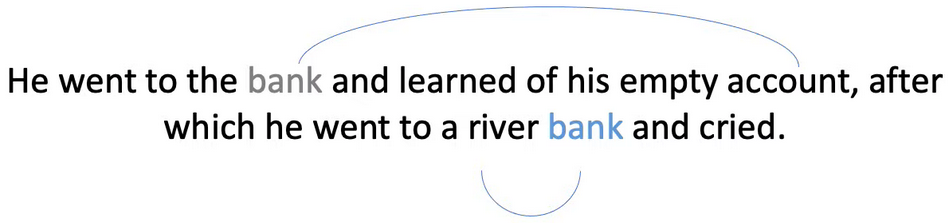
</div>

*Image credit to: [[Visual Guide to Transformer Neural Networks, 2020]](#References)*

In this sentence the word “bank” has two very different meanings. The difference is not based on the position though, but on the context, in this case primarily on the words “account” and “river”. In order to capture this difference in meaning of a word we need to construct relationships with the words surrounding it. This is exactly what the self-attention mechanism does.

Below, the output of one attention head is shown. You can see that it draws a relationship between the word “it” and “the animal” in the sentence “The animal didn't cross the street because it was too tired”. Note however, that there are 8 attention heads in each self-attention block that can each focus on a different part of a sentence.

<div>
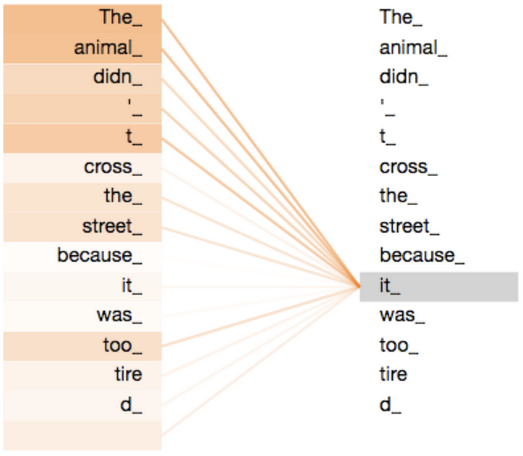
</div>

*Image credit to: [[Alammar, 2018]](#References)*

To visualize here is an example from computer vision. You can imagine the output of the attention heads like a filter that is being applied over the original input. Each attention head filters a different section of the sentence that is interrelated. In this visual example that is the women, the clouds and the rocks in the background. It’s the individual sections that are then being fed into a classic feed-forward neural network.

<div>
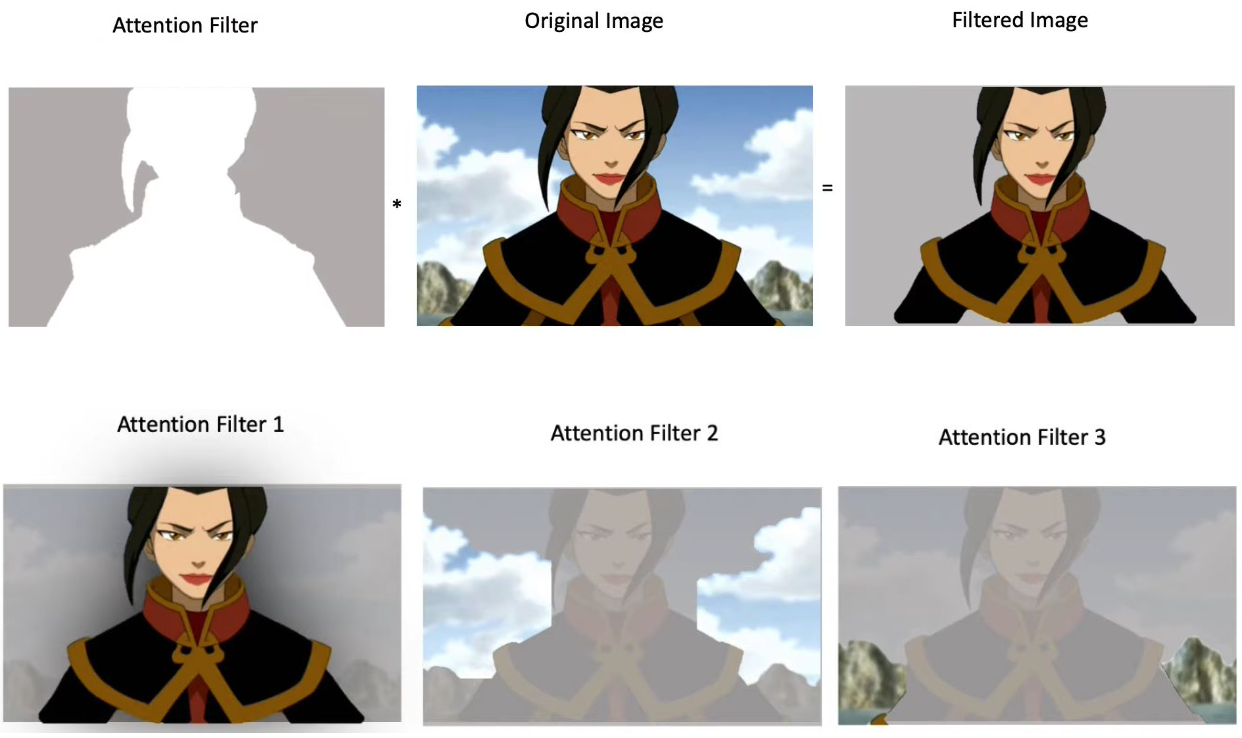
</div>

*Image credit to: [[Visual Guide to Transformer Neural Networks, 2020]](#References)*

Let's now take a closer look at what is going on inside of each attention head mathematically. Three identical copies of the embedded and positionally encoded sentence matrices are being passed into linear layers. Those copies are called query, key and value (Q, K, V) matrices, relating to how search engines worked back in the day. After being transformed by the linear layer, the query and key matrices are multiplied with each other to produce the attention matrix.

<div>
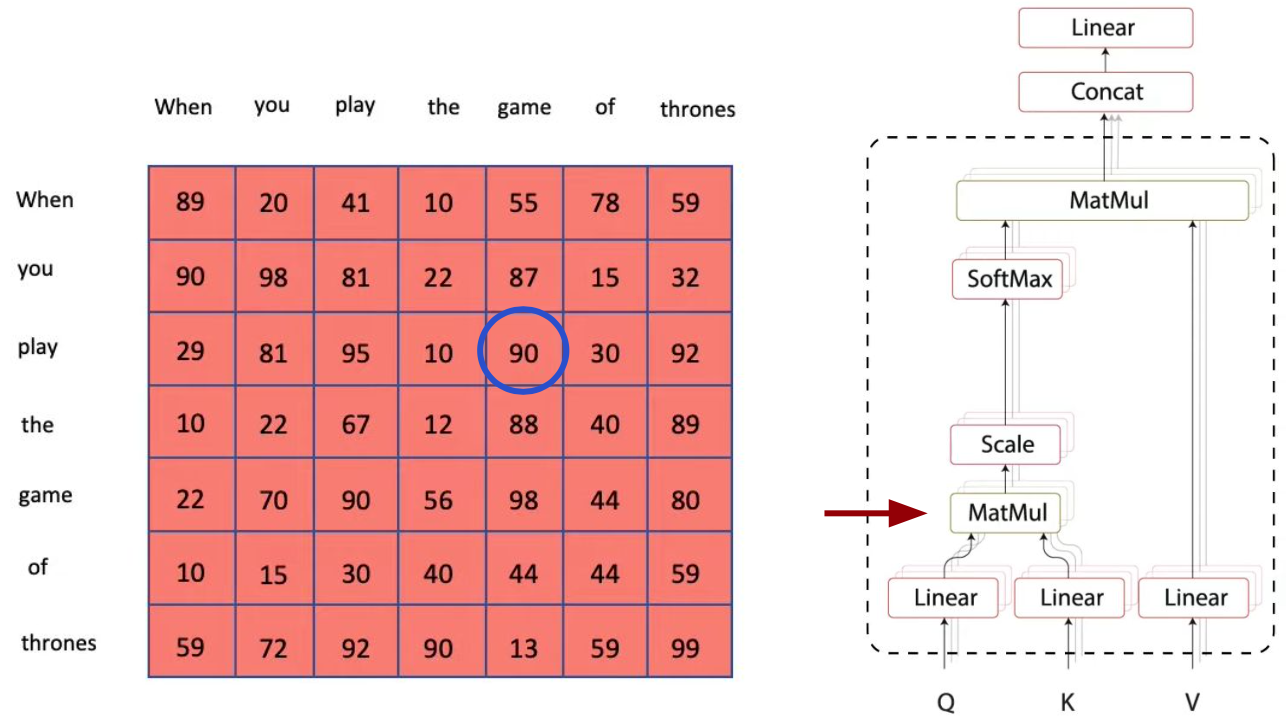
</div>

*Image credit to: [[Visual Guide to Transformer Neural Networks, 2020]](#References)*

In [33]:
# Toy example setup
tokens = ["When", "you", "play", "the", "game", "of", "thrones"]
embedding_dim = 4  # Small embedding dimension for simplicity
sequence_length = len(tokens)

# Create a dictionary of random embeddings
np.random.seed(42)  # For reproducibility
embeddings = {token: np.random.randint(1, 10, embedding_dim) for token in tokens}

# Create embedding matrix
input = np.array([embeddings[token] for token in tokens])  # Shape: (seq_len, embed_dim)

# Re-normalize embeddings to unit length for stability
input_normalized = input / np.linalg.norm(input, axis=1, keepdims=True)

output_df = pd.DataFrame(input_normalized, index=tokens, columns=[f"dim_{i}" for i in range(embedding_dim)])

print('Input Embeddings:\n', output_df)

Input Embeddings:
             dim_0     dim_1     dim_2     dim_3
When     0.564076  0.322329  0.644658  0.402911
you      0.535303  0.229416  0.535303  0.611775
play     0.384615  0.307692  0.615385  0.615385
the      0.348743  0.697486  0.581238  0.232495
game     0.704361  0.528271  0.176090  0.440225
of       0.091670  0.550019  0.825029  0.091670
thrones  0.240966  0.562254  0.321288  0.722897


In [ ]:
# Create Q, K, V weight matrices
W_Q = np.array([[1, 0, 0, 1],
                [0, 1, 1, 0],
                [1, 1, 0, 0],
                [0, 0, 1, 1]])

W_K = np.array([[1, 0, 1, 0],
                [0, 1, 0, 1],
                [1, 1, 0, 0],
                [0, 0, 1, 1]])

W_V = np.eye(4)  # Identity for transparency: V = X_normalized

# Compute Q, K, V
Q = input_normalized @ W_Q
K = input_normalized @ W_K
V = input_normalized @ W_V 

# Attention scores
attention_scores = ...  # Shape: (seq_len, seq_len)
attention_scores_df = pd.DataFrame(attention_scores, index=tokens, columns=tokens)
print("Attention Scores:\n", np.round(attention_scores_df, 2))

This is how the attention score matrix might look after training. One can see that this particular attention head reveals a presumed relationship between the words “play” and “game” by giving it a score of 90.

These attention scores are not bound though and still depend on the dimension of the matrix. The scores are therefore scaled down by the dimension and the softmax function is applied, transforming the scores into “attention probabilities” between 0 and 1.

<div>
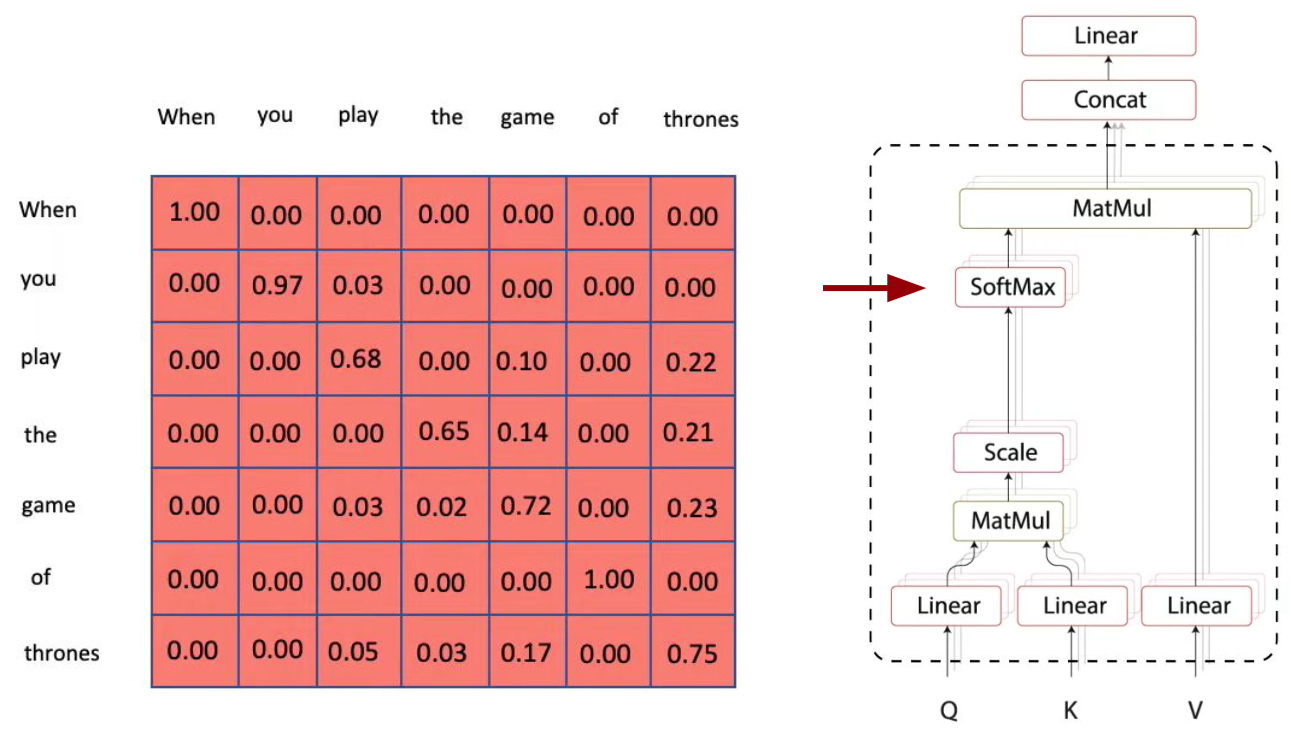
</div>

*Image credit to: [[Visual Guide to Transformer Neural Networks, 2020]](#References)*

These probabilities now function like the aforementioned attention filter and are multiplied with the value vectors to create the filtered sentence matrix. The resulting matrices of each attention head are concatenated together and go through another linear layer to produce one single matrix with the same dimensionality as the input matrices.

Putting it all together it results in the formula you're familiar with from the lecture:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^\top}{\sqrt{d}} \right) V
$$



In [ ]:
# Scale by sqrt(d_k)
dk = K.shape[1]
scaled_scores = ...

# Numerically stable softmax
def stable_softmax(x):
    x_max = np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x - x_max)
    sum_exp_x = np.sum(exp_x, axis=-1, keepdims=True)
    sum_exp_x[sum_exp_x == 0] = 1.0  # Prevent divide-by-zero
    return exp_x / sum_exp_x

# Compute attention weights and output
attention_weights = stable_softmax(scaled_scores)
output = ...

# Wrap for readable display
scaled_scores_df = pd.DataFrame(scaled_scores, index=tokens, columns=tokens)
attention_weights_df = pd.DataFrame(attention_weights, index=tokens, columns=tokens)
output_df = pd.DataFrame(output, index=tokens, columns=[f"dim_{i}" for i in range(embedding_dim)])

# Print results
print("\nScaled Scores:\n", np.round(scaled_scores_df, 2))
print("\nAttention Weights:\n", np.round(attention_weights_df, 2))
print("\nOutput:\n", np.round(output_df, 2))

Note: The the output dimension is once again the same as the input dimension, allowing for the stacking of Transformer Blocks on top of each other.

#### Addendum: Mathematical Interpretation

[Egri & Han 2021](https://egrigokhan.github.io/data/cs_229_br_Project_Report_KernelAttention.pdf) show that Transformer Attention can be viewed as a form of kernel method. The standard attention score is mathematically equivalent to an RBF kernel distance with a magnitude-dependent weighting term:

$$
a_{ij} = \frac{1}{Z_1(\alpha)} \exp\left( \frac{-\|q_i - k_j\|_2^2}{2\sqrt{d_k}} \right) \times \exp\left( \frac{\|q_i\|_2^2 + \|k_j\|_2^2}{2\sqrt{d_k}} \right)
$$

This decomposition shows that attention is not uniquely tied to the dot-product formulation -- it's just one choice of kernel. In principle, any positive-definite kernel could be used in place of the softmax-scaled dot-product, and the above mentioned paper shows that many perform on par or better for specific tasks.

## 4. Transformer Subtypes

BERT and GPT are two well known adaptations of the original sequence-to-sequence (seq2seq) transformer architecture. The original model uses an encoder-decoder setup suited for tasks like translation, summarization, or question answering. BERT drops the decoder and uses a bidirectional encoder trained with masked language modeling. It encodes text into a numeric representation, making it useful for classification tasks. GPT, on the other hand, uses only the decoder part, making it useful for autoregressive text generation.




## 5. Implementing a Transformer from scratch

In the following section we implement a transformer network from scratch in tensorflow, in order for you to see how the ideas presented in the lecture look like as python code. We will build a full sequence-to-sequence architecture with the task of translating from German to English.

### Install and load required packages

In [ ]:
import re
import sys
import collections
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib_inline
from IPython import display

### Set up tokenizers and vocabulary

In [ ]:
def preprocess_nmt(text):
    '''Preprocess the dataset.'''
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '
    # Replace non-breaking space with space, and convert uppercase letters to
    # lowercase ones
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # Insert space between words and punctuation marks
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)


def tokenize_nmt(text, num_examples=None):
    '''Tokenize the dataset.'''
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[1].split(' '))
            target.append(parts[0].split(' '))
    return source, target


def truncate_pad(line, num_steps, padding_token):
    '''Truncate or pad sequences.'''
    if len(line) > num_steps:
        return line[:num_steps]  # Truncate
    return line + [padding_token] * (num_steps - len(line))  # Pad


def build_array_nmt(lines, vocab, num_steps):
    '''Transform text sequences of machine translation into minibatches.'''
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = tf.constant([truncate_pad(
        l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = tf.reduce_sum(
        tf.cast(array != vocab['<pad>'], tf.int32), 1)
    return array, valid_len


def load_array(data_arrays, batch_size, is_train=True):
    '''Construct a TensorFlow data iterator.'''
    dataset = tf.data.Dataset.from_tensor_slices(data_arrays)
    if is_train:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    return dataset


def count_corpus(tokens):
    '''Count token frequencies.'''
    # Here `tokens` is a 1D list or 2D list
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # Flatten a list of token lists into a list of tokens
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)


class Vocab:
    '''Vocabulary for text.'''

    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # Sort according to frequencies
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        # The index for the unknown token is 0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # Index for the unknown token
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs


def load_data_nmt(raw_text, batch_size, num_steps, num_examples=600):
    ''' Return the iterator and the vocabularies of the translation dataset. '''
    text = preprocess_nmt(raw_text)
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=2,
                      reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2,
                      reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab


def sequence_mask(X, valid_len, value=0):
    '''Mask entries in sequences.'''
    maxlen = X.shape[1]
    mask = tf.range(start=0, limit=maxlen, dtype=tf.float32)[
        None, :] < tf.cast(valid_len[:, None], dtype=tf.float32)

    if len(X.shape) == 3:
        return tf.where(tf.expand_dims(mask, axis=-1), X, value)
    else:
        return tf.where(mask, X, value)

### Scaled Dot Product Attention



In [ ]:
class DotProductAttention(tf.keras.layers.Layer):
    '''Scaled dot product attention.'''

    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = tf.keras.layers.Dropout(dropout)
    # Shape of `queries`: (`batch_size`, no. of queries, `d`)
    # Shape of `keys`: (`batch_size`, no. of key-value pairs, `d`)
    # Shape of `values`: (`batch_size`, no. of key-value pairs, value
    # dimension)
    # Shape of `valid_lens`: (`batch_size`,) or (`batch_size`, no. of queries)

    @staticmethod
    def _masked_softmax(X, valid_lens):
        '''Perform softmax operation by masking elements on the last axis.'''
        # `X`: 3D tensor, `valid_lens`: 1D or 2D tensor
        if valid_lens is None:
            return tf.nn.softmax(X, axis=-1)
        else:
            shape = X.shape
            if len(valid_lens.shape) == 1:
                valid_lens = tf.repeat(valid_lens, repeats=shape[1])
            else:
                valid_lens = tf.reshape(valid_lens, shape=-1)
            # On the last axis, replace masked elements with a very large negative
            # value, whose exponentiation outputs 0
            X = sequence_mask(tf.reshape(
                X, shape=(-1, shape[-1])), valid_lens, value=-1e6)
            return tf.nn.softmax(tf.reshape(X, shape=shape), axis=-1)

    def call(self, queries, keys, values, valid_lens, **kwargs):
        d = queries.shape[-1]
        scores = tf.matmul(queries, keys, transpose_b=True)/tf.math.sqrt(
            tf.cast(d, dtype=tf.float32))
        self.attention_weights = self._masked_softmax(scores, valid_lens)
        return tf.matmul(self.dropout(self.attention_weights, **kwargs), values)

### Multi-Head Attention


In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    '''Multi-head Attention.'''

    def __init__(self, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = tf.keras.layers.Dense(num_hiddens, use_bias=bias)
        self.W_k = tf.keras.layers.Dense(num_hiddens, use_bias=bias)
        self.W_v = tf.keras.layers.Dense(num_hiddens, use_bias=bias)
        self.W_o = tf.keras.layers.Dense(num_hiddens, use_bias=bias)

    @staticmethod
    def _transpose_qkv(X, num_heads):
        '''Transposition for parallel computation of multiple attention heads.'''
        # Shape of input `X`:
        # (`batch_size`, no. of queries or key-value pairs, `num_hiddens`).
        # Shape of output `X`:
        # (`batch_size`, no. of queries or key-value pairs, `num_heads`,
        # `num_hiddens` / `num_heads`)
        X = tf.reshape(X, shape=(X.shape[0], X.shape[1], num_heads, -1))

        # Shape of output `X`:
        # (`batch_size`, `num_heads`, no. of queries or key-value pairs,
        # `num_hiddens` / `num_heads`)
        X = tf.transpose(X, perm=(0, 2, 1, 3))

        # Shape of `output`:
        # (`batch_size` * `num_heads`, no. of queries or key-value pairs,
        # `num_hiddens` / `num_heads`)
        return tf.reshape(X, shape=(-1, X.shape[2], X.shape[3]))

    @staticmethod
    def _transpose_output(X, num_heads):
        '''Reverse the operation of `transpose_qkv`.'''
        X = tf.reshape(X, shape=(-1, num_heads, X.shape[1], X.shape[2]))
        X = tf.transpose(X, perm=(0, 2, 1, 3))
        return tf.reshape(X, shape=(X.shape[0], X.shape[1], -1))

    def call(self, queries, keys, values, valid_lens, **kwargs):
        # Shape of `queries`, `keys`, or `values`:
        # (`batch_size`, no. of queries or key-value pairs, `num_hiddens`)
        # Shape of `valid_lens`:
        # (`batch_size`,) or (`batch_size`, no. of queries)
        # After transposing, shape of output `queries`, `keys`, or `values`:
        # (`batch_size` * `num_heads`, no. of queries or key-value pairs,
        # `num_hiddens` / `num_heads`)
        queries = self._transpose_qkv(self.W_q(queries), self.num_heads)
        keys = self._transpose_qkv(self.W_k(keys), self.num_heads)
        values = self._transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            # On axis 0, copy the first item (scalar or vector) for
            # `num_heads` times, then copy the next item, and so on
            valid_lens = tf.repeat(valid_lens, repeats=self.num_heads, axis=0)

        # Shape of `output`: (`batch_size` * `num_heads`, no. of queries,
        # `num_hiddens` / `num_heads`)
        output = self.attention(queries, keys, values, valid_lens, **kwargs)

        # Shape of `output_concat`: (`batch_size`, no. of queries,
        # `num_hiddens`)
        output_concat = self._transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

### Positional Encoding



In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):
    '''Positional Encoding.'''

    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.P = np.zeros((1, max_len, num_hiddens))
        X = np.arange(max_len, dtype=np.float32).reshape(
            -1, 1)/np.power(10000, np.arange(
                0, num_hiddens, 2, dtype=np.float32) / num_hiddens)
        self.P[:, :, 0::2] = np.sin(X)
        self.P[:, :, 1::2] = np.cos(X)

### Transformer Blocks



In [41]:
class PositionWiseFFN(tf.keras.layers.Layer):
    '''Positionwise feed-forward network.'''

    def __init__(self, ffn_num_hiddens, ffn_num_outputs, **kwargs):
        super().__init__(*kwargs)
        self.dense1 = tf.keras.layers.Dense(ffn_num_hiddens)
        self.relu = tf.keras.layers.ReLU()
        self.dense2 = tf.keras.layers.Dense(ffn_num_outputs)

    def call(self, X):
        return self.dense2(self.relu(self.dense1(X)))


class AddNorm(tf.keras.layers.Layer):
    '''Residual connection followed by layer normalization.'''

    def __init__(self, normalized_shape, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.ln = tf.keras.layers.LayerNormalization(normalized_shape)

    def call(self, X, Y, **kwargs):
        return self.ln(self.dropout(Y, **kwargs) + X)


class EncoderBlock(tf.keras.layers.Layer):
    '''Transformer encoder block.'''

    def __init__(self, num_hiddens, norm_shape, ffn_num_hiddens, num_heads,
                 dropout, bias=False, **kwargs):
        super().__init__(**kwargs)
        self.attention = MultiHeadAttention(num_hiddens, num_heads, dropout, bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def call(self, X, valid_lens, **kwargs):
        Y = self.addnorm1(X, self.attention(
            X, X, X, valid_lens, **kwargs), **kwargs)
        return self.addnorm2(Y, self.ffn(Y), **kwargs)


class TransformerEncoder(tf.keras.layers.Layer):
    '''Transformer encoder.'''

    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_hiddens,
                 num_heads, num_layers, dropout, bias=False, **kwargs):
        super().__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = tf.keras.layers.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = [EncoderBlock(num_hiddens, norm_shape,
            ffn_num_hiddens, num_heads, dropout, bias) for _ in range(
            num_layers)]

    def call(self, X, valid_lens, **kwargs):
        # Since positional encoding values are between -1 and 1, the embedding
        # values are multiplied by the square root of the embedding dimension
        # to rescale before they are summed up
        X = self.pos_encoding(self.embedding(X) * tf.math.sqrt(
            tf.cast(self.num_hiddens, dtype=tf.float32)), **kwargs)
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens, **kwargs)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X


class DecoderBlock(tf.keras.layers.Layer):
    '''The `i`-th block in the decoder.'''

    def __init__(self, num_hiddens, norm_shape, ffn_num_hiddens,
                 num_heads, dropout, i, **kwargs):
        super().__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def call(self, X, state, **kwargs):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # During training, all the tokens of any output sequence are processed
        # at the same time, so `state[2][self.i]` is `None` as initialized.
        # When decoding any output sequence token by token during prediction,
        # `state[2][self.i]` contains representations of the decoded output at
        # the `i`-th block up to the current time step
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = tf.concat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if kwargs["training"]:
            batch_size, num_steps, _ = X.shape
            # Shape of `dec_valid_lens`: (`batch_size`, `num_steps`), where
            # every row is [1, 2, ..., `num_steps`]
            dec_valid_lens = tf.repeat(tf.reshape(tf.range(1, num_steps + 1),
                                                  shape=(-1, num_steps)), repeats=batch_size, axis=0)

        else:
            dec_valid_lens = None

        # Self-attention
        X2 = self.attention1(X, key_values, key_values,
                             dec_valid_lens, **kwargs)
        Y = self.addnorm1(X, X2, **kwargs)
        # Encoder-decoder attention. Shape of `enc_outputs`: (`batch_size`, `num_steps`, `num_hiddens`)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs,
                             enc_valid_lens, **kwargs)
        Z = self.addnorm2(Y, Y2, **kwargs)
        return self.addnorm3(Z, self.ffn(Z), **kwargs), state


class TransformerDecoder(tf.keras.layers.Layer):
    '''Transformer decoder.'''

    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super().__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = [DecoderBlock(num_hiddens, norm_shape, ffn_num_hiddens, num_heads, dropout, i)
                     for i in range(num_layers)]
        self.dense = tf.keras.layers.Dense(vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def call(self, X, state, **kwargs):
        X = self.pos_encoding(self.embedding(
            X) * tf.math.sqrt(tf.cast(self.num_hiddens, dtype=tf.float32)), **kwargs)
        # 2 Attention layers in decoder
        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state, **kwargs)
            # Decoder self-attention weights
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            # Encoder-decoder attention weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights


### Transformer Encoder-Decoder Architecture



In [ ]:
class EncoderDecoder(tf.keras.Model):
    '''Class for the encoder-decoder architecture.'''

    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, enc_X, dec_X, *args, **kwargs):
        enc_outputs = self.encoder(enc_X, *args, **kwargs)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state, **kwargs)
    
    @staticmethod
    def __grad_clipping(grads, theta):
        '''Clip the gradient.'''
        theta = tf.constant(theta, dtype=tf.float32)
        new_grad = []
        for grad in grads:
            if isinstance(grad, tf.IndexedSlices):
                new_grad.append(tf.convert_to_tensor(grad))
            else:
                new_grad.append(grad)
        norm = tf.math.sqrt(sum((tf.reduce_sum(grad ** 2)).numpy()
                            for grad in new_grad))
        norm = tf.cast(norm, tf.float32)
        if tf.greater(norm, theta):
            for i, grad in enumerate(new_grad):
                new_grad[i] = grad * theta / norm
        else:
            new_grad = new_grad
        return new_grad

    def train(self, data_iter, lr, num_epochs, tgt_vocab):
        if len(tf.config.experimental.list_physical_devices('GPU')) >= 1:
            device = tf.device(f'/GPU:1')
        else:
            device = tf.device('/CPU:0')

        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=lr)
        animator = Animator(xlabel="epoch", ylabel="loss",
                            xlim=[10, num_epochs])
        for epoch in range(num_epochs):
            metric = Accumulator(2)  # Sum of training loss, no. of tokens
            for batch in data_iter:
                X, X_valid_len, Y, Y_valid_len = [x for x in batch]
                bos = tf.reshape(tf.constant([tgt_vocab['<bos>']] * Y.shape[0]),
                                 shape=(-1, 1))
                dec_input = tf.concat([bos, Y[:, :-1]], 1)  # Teacher forcing
                with tf.GradientTape() as tape:
                    Y_hat, _ = self(X, dec_input, X_valid_len, training=True)
                    l = MaskedSoftmaxCELoss(Y_valid_len)(Y, Y_hat)
                gradients = tape.gradient(l, self.trainable_variables)
                gradients = self.__grad_clipping(gradients, 1)
                optimizer.apply_gradients(
                    zip(gradients, self.trainable_variables))
                num_tokens = tf.reduce_sum(Y_valid_len).numpy()
                metric.add(tf.reduce_sum(l), num_tokens)
            if (epoch + 1) % 10 == 0:
                animator.add(epoch + 1, (metric[0] / metric[1],))
        print(f'loss {metric[0] / metric[1]:.3f}'
              f'tokens/sec on {str(device)}')


class MaskedSoftmaxCELoss(tf.keras.losses.Loss):
    '''The softmax cross-entropy loss with masks.'''

    def __init__(self, valid_len):
        super().__init__(reduction='none')
        self.valid_len = valid_len

    # `pred` shape: (`batch_size`, `num_steps`, `vocab_size`)
    # `label` shape: (`batch_size`, `num_steps`)
    # `valid_len` shape: (`batch_size`,)
    def call(self, label, pred):
        weights = tf.ones_like(label, dtype=tf.float32)
        weights = sequence_mask(weights, self.valid_len)
        label_one_hot = tf.one_hot(label, depth=pred.shape[-1])
        unweighted_loss = tf.keras.losses.CategoricalCrossentropy(
            from_logits=True, reduction='none')(label_one_hot, pred)
        weighted_loss = tf.reduce_mean((unweighted_loss*weights), axis=1)
        return weighted_loss


class Animator:
    '''For plotting data in animation.'''

    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # Incrementally plot multiple lines
        if legend is None:
            legend = []
        matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Use a lambda function to capture arguments
        self.config_axes = lambda: self.__set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    @staticmethod
    def __set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
        '''Set the axes for matplotlib.'''
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabel)
        axes.set_xscale(xscale)
        axes.set_yscale(yscale)
        axes.set_xlim(xlim)
        axes.set_ylim(ylim)
        if legend:
            axes.legend(legend)
        axes.grid()

    def add(self, x, y):
        # Add multiple data points into the figure
        if not hasattr(y, '__len__'):
            y = [y]
        n = len(y)
        if not hasattr(x, '__len__'):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)


class Accumulator:
    '''For accumulating sums over `n` variables.'''

    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

## Applying the Seq2seq Transformer for translation

The network will have the task of translating from German to English and will be trained on a dataset of German-English sentence pairs from the [Tatoeba](https://tatoeba.org/) project which is also found on the DeLTA Moodle page.

Tatoeba is a collbaorative platform where everyone can add sentences and their translation in a certain language. The resulting sentence pairs can be downloaded as an open-source dataset. The advantage of the Tatoeba dataset is that one phrase may have different translations from different users. The main disadvantage is that most sentences are short, because collaborators usually do not tend to think of very long sentences when adding entries. We will see how this becomes a problem later on.

### First step: Load the data

Mount the drive (if you're using Colab) and please make sure that you upload the file "sentence_pairs_for_nmt.txt" into the same as directory as this notebook.

In [43]:
colab = False

if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive')
    path = '/content/drive/MyDrive/'
else:
    path = './'

Load German-English sentence pairs

In [ ]:
def read_data(name):
    with open(path + name, 'r') as f:
        return f.read()

raw_text = read_data('sentence_pairs_for_nmt.txt')

It should show roughly 1.2 million sentence pairs

In [ ]:
len(raw_text.splitlines())

1248310

### Set hyperparameters and train our transformer for German-English translation

loss 0.024tokens/sec on <tensorflow.python.eager.context._EagerDeviceContext object at 0x435abe700>


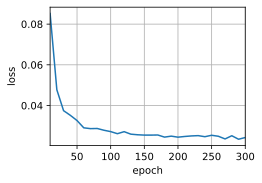

In [ ]:
config = {
    'num_hiddens': 32,
    'norm_shape': [2],
    'ffn_num_hiddens': 64,
    'num_heads': 4,
    'num_layers': 2,
    'dropout': 0.1,
}
train_iter, src_vocab, tgt_vocab = load_data_nmt(
    raw_text=raw_text,
    batch_size=64,
    num_steps=10,
)
encoder = TransformerEncoder(vocab_size=len(src_vocab), **config)
decoder = TransformerDecoder(vocab_size=len(tgt_vocab), **config)
network = EncoderDecoder(encoder, decoder)
network.train(
    data_iter=train_iter,
    lr=0.005,
    num_epochs=300,
    tgt_vocab=tgt_vocab,
)

### Now, lets translate a couple of test sentences to see how the model performs

In [ ]:
def translate(src_sentence: str, num_steps: int = 20):
    '''Translate from German to English.'''
    src_sentence = preprocess_nmt(src_sentence)
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [
        src_vocab['<eos>']]
    enc_valid_len = tf.constant([len(src_tokens)])
    src_tokens = truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    # Add the batch axis
    enc_X = tf.expand_dims(src_tokens, axis=0)
    enc_outputs = network.encoder(enc_X, enc_valid_len, training=False)
    dec_state = network.decoder.init_state(enc_outputs, enc_valid_len)
    # Add the batch axis
    dec_X = tf.expand_dims(tf.constant([tgt_vocab['<bos>']]), axis=0)
    output_seq = []
    for _ in range(num_steps):
        Y, dec_state = network.decoder(dec_X, dec_state, training=False)
        # We use the token with the highest prediction likelihood as the input
        # of the decoder at the next time step
        dec_X = tf.argmax(Y, axis=2)
        pred = tf.squeeze(dec_X, axis=0)
        # Save attention weights
        # Once the end-of-sequence token is predicted, the generation of the
        # output sequence is complete
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred.numpy())
    translation = ' '.join(tgt_vocab.to_tokens(tf.reshape(output_seq, shape = -1).numpy().tolist()))
    translation_processed = re.sub(
        r'\s([?.!"](?:\s|$))', r'\1', translation).capitalize()
    return translation_processed

In [36]:
translate('Wie schön!')

'How nice!'

In [ ]:
input_sentences = ['Hallo.',
                   'Warte!',
                   'Geh weg.',
                   'Im Ernst?',
                   'Ruf mich an.',
                   'Ich bin wieder da.',
                   'Ich habe eine Glatze.',
                   'Das darf nicht wahr sein!',
                   'Was kann ich für dich tun?',
                   'Es ist schlimmer als gedacht!']
                   
for sentence in input_sentences:
    translation = translate(sentence)
    print(f'{sentence} >> {translation}')

Hallo. >> Hi.
Warte! >> Hold it!
Geh weg. >> Go away.
Im Ernst? >> Really?
Ruf mich an. >> Call me.
Ich bin wieder da. >> I'm back.
Ich habe eine Glatze. >> I'm bald.
Das darf nicht wahr sein! >> No way!
Was kann ich für dich tun? >> Can i go?
Es ist schlimmer als gedacht! >> How sad!


As you can see, the network only produces very short results. Therefore the translation accuracy is decent for short inputs, but for longer sentences the network seems to just match it to best two or three letter phrase it can 'think' of. Likely, the reason for that is that the Tatoeba dataset consists mostly of very short phrases.

In any case, for such a short training time, this is a very good result. 

## References

[Agarwal, 2021] 

&ensp;&ensp;&ensp; *Agarwal, Neeraj. “The Ultimate Guide to Different Word Embedding Techniques in NLP.” KDnuggets, 2021, www.kdnuggets.com/2021/11/guide-word-embedding-techniques-nlp.html. Accessed 2 Feb. 2022*

[Alammar, 2018]

&ensp;&ensp;&ensp; *Alammar, J. (2018). The Illustrated Transformer. Jalammar.github.io. https://jalammar.github.io/illustrated-transformer/*
‌

[Bahdanau et al., 2014]

&ensp;&ensp;&ensp; *Bahdanau, D., Cho, K., & Bengio, Y. (2014). Neural Machine Translation by Jointly Learning to Align and Translate. ArXiv.org. https://arxiv.org/abs/1409.0473*

‌
[Visual Guide to Transformer Neural Networks, 2020]

&ensp;&ensp;&ensp; *Visual Guide to Transformer Neural Networks - (Episode 2) Multi-Head & Self-Attention. (2020). Www.youtube.com. Retrieved February 4, 2022, from https://www.youtube.com/watch?v=mMa2PmYJlCo&t=591s*

[Bahdanau et al., 2016] 

&ensp;&ensp;&ensp; *Bahdanau, D., Chorowski, J., Serdyuk, D., Brakel, P., and Bengio, Y. (2016). End-to-end attention-based large vocabulary speech recognition. In 2016 IEEE international conference on acoustics, speech and signal processing (ICASSP), pages 4945–4949. IEEE.*

‌[Chorowski et al., 2015] 

&ensp;&ensp;&ensp; *Chorowski, J. K., Bahdanau, D., Serdyuk, D., Cho, K., and Bengio, Y. (2015). Attention-based models for speech recognition. Advances in neural information processing systems, 28.*

[Chungetal.,2014] 

&ensp;&ensp;&ensp; *Chung,J.,Gulcehre,C.,Cho,K.,andBengio,Y.(2014). Empirical evaluation of gated recurrent neural networks on sequence modeling. arXiv preprint arXiv:1412.3555.*

[Colyer, 2016] 

&ensp;&ensp;&ensp; *Colyer, Adrian. The Amazing Power of Word Vectors | the Morning Paper. 16 Apr. 2016 blog.acolyer.org/2016/04/21/the-amazing-power-of-word-vectors/. Accessed 3 Feb. 2022.*

[Cristina, 2021] 

&ensp;&ensp;&ensp; *Cristina, Stefania. “The Transformer Model.” Machine Learning Mastery, 3 Nov. 2021, machinelearningmastery.com/the-transformer-model/. Accessed 2 Feb. 2022.*

[Dauphin et al., 2017] 

&ensp;&ensp;&ensp; *Dauphin, Y. N., Fan, A., Auli, M., and Grangier, D. (2017). Language modeling with gated convolutional networks. In International conference on machine learning, pages 933–941. PMLR.*

[Desagulier, 2018] 

&ensp;&ensp;&ensp; *Desagulier, Guillaume. “Word Embeddings: The (Very) Basics.” Around the Word, 25 Apr. 2018, corpling.hypotheses.org/495. Accessed 3 Feb. 2022.*

[Gehring et al., 2017] 

&ensp;&ensp;&ensp; *Gehring, J., Auli, M., Grangier, D., Yarats, D., and Dauphin, Y. N. (2017). Convolutional sequence to sequence learning. In International Conference on Machine Learning, pages 1243–1252. PMLR.*

[He et.al., 2016] 

&ensp;&ensp;&ensp; *He, Kaiming, et al. “Identity Mappings in Deep Residual Networks.” Computer Vision – ECCV 2016, 2016, pp. 630–645, link.springer.com/chapter/10.1007%2F978-3-319-46493-0_38, 10.1007/978-3-319-46493-0_38.*

[Hochreiter and Schmidhuber, 1997] 

&ensp;&ensp;&ensp; *Hochreiter, S. and Schmidhuber, J. (1997). Long short-term memory. Neural computation, 9(8):1735–1780.*

[Joshi, 2019]  

&ensp;&ensp;&ensp; *Joshi, Prateek. “Transformers in NLP | State-Of-The-Art-Models.” Analytics Vidhya, 19 June 2019, www.analyticsvidhya.com/blog/2019/06/understanding-transformers-nlp-state-of-the-art-models/.*

[Nallapati et al., 2017] 

&ensp;&ensp;&ensp; *Nallapati, R., Zhai, F., and Zhou, B. (2017). Sum- marunner: A recurrent neural network based sequence model for extractive summarization of documents. In Thirty-first AAAI conference on artificial intelligence.*

[Nallapatietal.,2016] 

&ensp;&ensp;&ensp; *Nallapati,R.,Zhou,B.,Gulcehre,C.,Xiang,B.,etal. (2016). Abstractive text summarization using sequence-to-sequence rnns and beyond. arXiv preprint arXiv:1602.06023.*

[Rush et al., 2015] 

&ensp;&ensp;&ensp; *Rush, A. M., Chopra, S., and Weston, J. (2015). A neural attention model for abstractive sentence summarization. arXiv preprint arXiv:1509.00685.*

[Sutskever et al., 2014] 

&ensp;&ensp;&ensp; *Sutskever, I., Vinyals, O., and Le, Q. V. (2014). Sequence to sequence learning with neural networks. Advances in neural information processing systems, 27.*

[Vasilev, 2019] 

&ensp;&ensp;&ensp; *Vasilev, Ivan. Advanced Deep Learning with Python : Design and Implement Adavnced Next-Generation AI Solutions Using TensorFlow and PyTorch. Birmingham, Uk, Packt Publishing, 2019.*

[Vaswani at al., 2017] 

&ensp;&ensp;&ensp; *Vaswani, Ashish, et al. “Attention Is All You Need.” ArXiv.org, 2017, arxiv.org/abs/1706.03762.*

[Venugopalan et al., 2015] 

&ensp;&ensp;&ensp; *Venugopalan, S., Rohrbach, M., Donahue, J., Mooney, R., Darrell, T., and Saenko, K. (2015). Sequence to sequence- video to text. In Proceedings of the IEEE international conference on computer vision, pages 4534–4542.*

[Yin and Pei, 2015] 

&ensp;&ensp;&ensp; *Yin, W. and Pei, Y. (2015). Optimizing sentence modeling and selection for document summarization. In Twenty-Fourth International Joint Conference on Artificial Intelligence.*